In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve, confusion_matrix, classification_report

print(f"✅ Imports OK | PyTorch version : {torch.__version__}")

✅ Imports OK | PyTorch version : 2.10.0+cpu


In [2]:
X_train = np.load("../data/X_train_res.npy")
y_train = np.load("../data/y_train_res.npy")
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")

# Autoencoder : on entraîne UNIQUEMENT sur les transactions normales
X_train_normal = X_train[y_train == 0]

print(f"Train normal : {X_train_normal.shape}")
print(f"Test : {X_test.shape}")

Train normal : (45490, 29)
Test : (56962, 29)


In [3]:
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(FraudAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)   # Bottleneck
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_train_normal.shape[1]
model = FraudAutoencoder(input_dim)
print(model)
print(f"\n✅ Modèle créé | Input dim : {input_dim}")

FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=29, bias=True)
  )
)

✅ Modèle créé | Input dim : 29


Epoch 10/50 | Loss : 0.487320
Epoch 20/50 | Loss : 0.439524
Epoch 30/50 | Loss : 0.415964
Epoch 40/50 | Loss : 0.399971
Epoch 50/50 | Loss : 0.388514


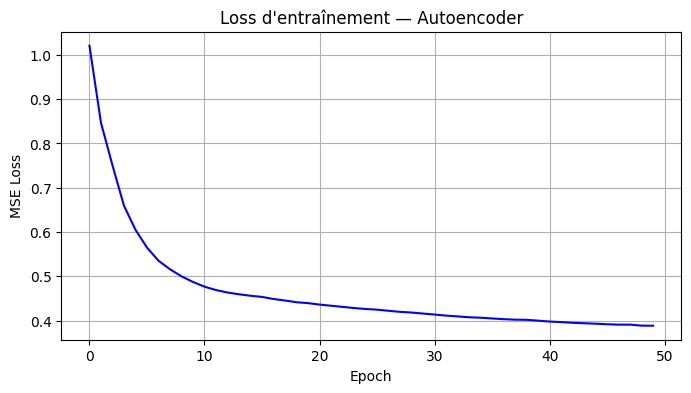

In [4]:
# Hyperparamètres
EPOCHS = 50
BATCH_SIZE = 256
LEARNING_RATE = 0.001

# DataLoader
X_tensor = torch.FloatTensor(X_train_normal)
dataset = TensorDataset(X_tensor, X_tensor)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Optimiseur et loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

# Entraînement
losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_X, _ in loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_X)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss : {avg_loss:.6f}")

# Courbe de loss
plt.figure(figsize=(8,4))
plt.plot(losses, color='blue')
plt.title("Loss d'entraînement — Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [5]:
model.eval()
X_test_tensor = torch.FloatTensor(X_test)

with torch.no_grad():
    X_reconstructed = model(X_test_tensor)

# Erreur de reconstruction = score d'anomalie
reconstruction_errors = torch.mean(
    (X_test_tensor - X_reconstructed) ** 2, dim=1
).numpy()

# Seuil = percentile 95
threshold = np.percentile(reconstruction_errors, 95)
y_pred = (reconstruction_errors > threshold).astype(int)

print(f"Seuil de détection : {threshold:.6f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Normal', 'Fraude'])}")

Seuil de détection : 0.952251

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98     56864
      Fraude       0.03      0.90      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.92      0.52     56962
weighted avg       1.00      0.95      0.97     56962



AUPRC Autoencoder : 0.5118


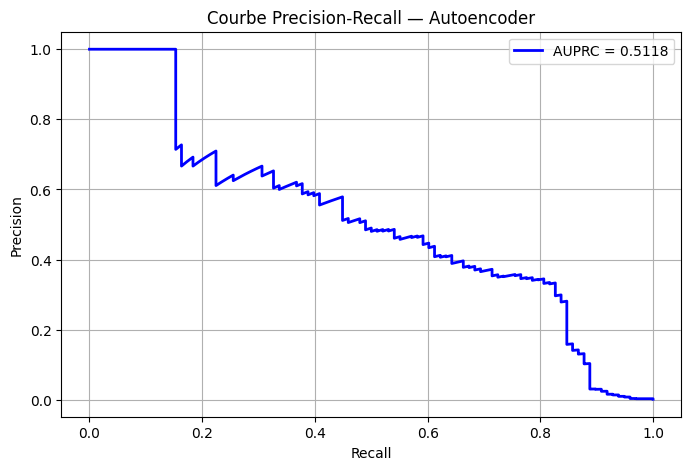


Vrais Positifs (fraudes détectées)   : 88
Faux Positifs (blocages injustifiés) : 2761
Faux Négatifs (fraudes manquées)     : 10

Coût financier estimé : 32610€
  - FP (2761 x 10€) = 27610€
  - FN (10 x 500€) = 5000€


In [6]:
# AUPRC
auprc = average_precision_score(y_test, reconstruction_errors)
print(f"AUPRC Autoencoder : {auprc:.4f}")

precision, recall, _ = precision_recall_curve(y_test, reconstruction_errors)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='blue', lw=2, label=f'AUPRC = {auprc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Autoencoder')
plt.legend()
plt.grid(True)
plt.show()

# Coût financier
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

cout_FP = 10
cout_FN = 500
cout_total = (FP * cout_FP) + (FN * cout_FN)

print(f"\nVrais Positifs (fraudes détectées)   : {TP}")
print(f"Faux Positifs (blocages injustifiés) : {FP}")
print(f"Faux Négatifs (fraudes manquées)     : {FN}")
print(f"\nCoût financier estimé : {cout_total}€")
print(f"  - FP ({FP} x {cout_FP}€) = {FP*cout_FP}€")
print(f"  - FN ({FN} x {cout_FN}€) = {FN*cout_FN}€")